# Fase 2 — Aprendizaje de Máquina
## Clasificación de Género en Twitter · Ensemble Methods (Random Forest)

**Curso:** Sistemas Inteligentes · Pontificia Universidad Javeriana  
**Técnica:** Random Forest + Gradient Boosting (Métodos de Ensamble)  
**Referencia principal:** Vashisth et al. (2021) *Gender Classification using Twitter Text Data* — IEEE ICCMC

---
### Moralejas aplicadas desde los papers:
- **Paper 1 (Vashisth 2021):** RF y XGBoost superan a LR/MLP en TF-IDF; añadir **meta-features** (longitud, puntuación, mayúsculas) mejora resultados → *aplicado en Sección 2*
- **Paper 2 (Yang 2021):** Meta-clasificador (stacking) es superior a cualquier modelo individual → *aplicado como experimento adicional en Sección 4*
- **Paper 3 (Ensemble DL 2020):** Combinar múltiples espacios de features (texto + metadatos) eleva el desempeño → *aplicado combinando TF-IDF + meta-features*

## 0 · Instalación de dependencias

In [ ]:
# Solo correr la primera vez
#pip install gradio scikit-learn pandas numpy matplotlib seaborn wordcloud

SyntaxError: invalid syntax (3476243991.py, line 2)

## 1 · Carga de datos y pipeline existente

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from scipy.sparse import hstack, csr_matrix
import joblib

print('Librerías cargadas')

✅ Librerías cargadas


In [4]:

DATA_PATH = '../data/gender-classifier-clean.csv'  # <--- Cuidado la ubicacion

# Columnas esperadas (ajustar según el dataset del repo)
TEXT_COL   = 'text'          # columna con el texto del tweet
LABEL_COL  = 'gender'        # columna con la etiqueta (male/female o 0/1)

df = pd.read_csv(DATA_PATH)
print(f'Dataset cargado: {df.shape[0]} filas · {df.shape[1]} columnas')
print(f'Distribución de clases:\n{df[LABEL_COL].value_counts()}')
df.head(3)

Dataset cargado: 18836 filas · 26 columnas
Distribución de clases:
gender
female    6700
male      6194
brand     5942
Name: count, dtype: int64


,gender,description,text,name,desc_length,desc_word_count,text_length,text_word_count,name_length,fav_number,...,link_color_g,link_color_b,sidebar_color_r,sidebar_color_g,sidebar_color_b,tweet_location,user_timezone,account_age_days,created_year,created_month
0,male,i sing my own rhythm.,Robbie E Responds To Critics After Win Against...,sheezy0,21,5,109,14,7,0,...,0.760784,0.760784,1.000000,1.000000,1.000000,main; @Kan1shk3,Chennai,689,2013,12
1,male,I'm the author of novels filled with family dr...,ÛÏIt felt like they were my friends and I was...,DavdBurnett,62,11,139,19,11,68,...,0.517647,0.705882,0.752941,0.870588,0.929412,unknown,Eastern Time (US & Canada),1119,2012,10
2,male,louis whining and squealing and all,i absolutely adore when louis starts the songs...,lwtprettylaugh,35,6,80,16,14,7696,...,0.721569,0.760784,0.752941,0.870588,0.929412,clcncl,Belgrade,331,2014,11


In [9]:
# Filtrar solo male/female (eliminar brand)
df = df[df[LABEL_COL].isin(['male', 'female'])].copy()
df['label'] = df[LABEL_COL].map({'female': 0, 'male': 1})
df = df.dropna(subset=[TEXT_COL, 'label'])
df[TEXT_COL] = df[TEXT_COL].astype(str)

X_text = df[TEXT_COL].values
y = df['label'].values

print(f'Datos listos: {len(X_text)} muestras (brand excluido)')
print(f'Balance: {(y==0).sum()} female | {(y==1).sum()} male')

Datos listos: 12894 muestras (brand excluido)
Balance: 6700 female | 6194 male


## 2 · Feature Engineering
**Aplicando moraleja del Paper 1 (Vashisth 2021):** añadir meta-features lingüísticos sobre TF-IDF base mejora el desempeño de los modelos de ensamble.

In [10]:
def extract_meta_features(texts):
    """
    Meta-features lingüísticos inspirados en Vashisth et al. (2021):
    Variables experimentales: longitud, puntuación, mayúsculas, etc.
    """
    features = []
    for text in texts:
        text = str(text)
        words = text.split()
        n_chars     = len(text)
        n_words     = len(words)
        n_upper     = sum(1 for c in text if c.isupper())
        n_punct     = sum(1 for c in text if c in '!?.,;:')
        n_excl      = text.count('!')
        n_question  = text.count('?')
        n_hashtag   = text.count('#')
        n_mention   = text.count('@')
        n_emoji     = sum(1 for c in text if ord(c) > 127)
        avg_word_len = np.mean([len(w) for w in words]) if words else 0
        upper_ratio  = n_upper / max(n_chars, 1)
        punct_ratio  = n_punct / max(n_chars, 1)

        features.append([
            n_chars, n_words, n_upper, n_punct, n_excl,
            n_question, n_hashtag, n_mention, n_emoji,
            avg_word_len, upper_ratio, punct_ratio
        ])

    cols = [
        'n_chars', 'n_words', 'n_upper', 'n_punct', 'n_exclamation',
        'n_question', 'n_hashtag', 'n_mention', 'n_emoji',
        'avg_word_len', 'upper_ratio', 'punct_ratio'
    ]
    return pd.DataFrame(features, columns=cols)

meta_df = extract_meta_features(X_text)
print('Meta-features extraídos:')
meta_df.describe().round(3)

Meta-features extraídos:


,n_chars,n_words,n_upper,n_punct,n_exclamation,n_question,n_hashtag,n_mention,n_emoji,avg_word_len,upper_ratio,punct_ratio
count,12894.000,12894.000,12894.000,12894.000,12894.000,12894.000,12894.000,12894.000,12894.000,12894.000,12894.000,12894.000
mean,96.867,16.043,7.551,2.284,0.212,0.119,0.290,0.516,1.233,5.314,0.079,0.023
std,33.839,6.098,9.685,2.209,0.725,0.466,0.814,0.799,4.176,1.898,0.100,0.021
min,6.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2.143,0.000,0.000
25%,70.000,11.000,2.000,0.000,0.000,0.000,0.000,0.000,0.000,4.278,0.029,0.000
50%,100.000,16.000,5.000,2.000,0.000,0.000,0.000,0.000,0.000,5.000,0.054,0.020
75%,128.000,21.000,9.000,3.000,0.000,0.000,0.000,1.000,0.000,6.000,0.095,0.034
max,425.000,33.000,120.000,22.000,17.000,12.000,12.000,9.000,190.000,115.000,0.968,0.210


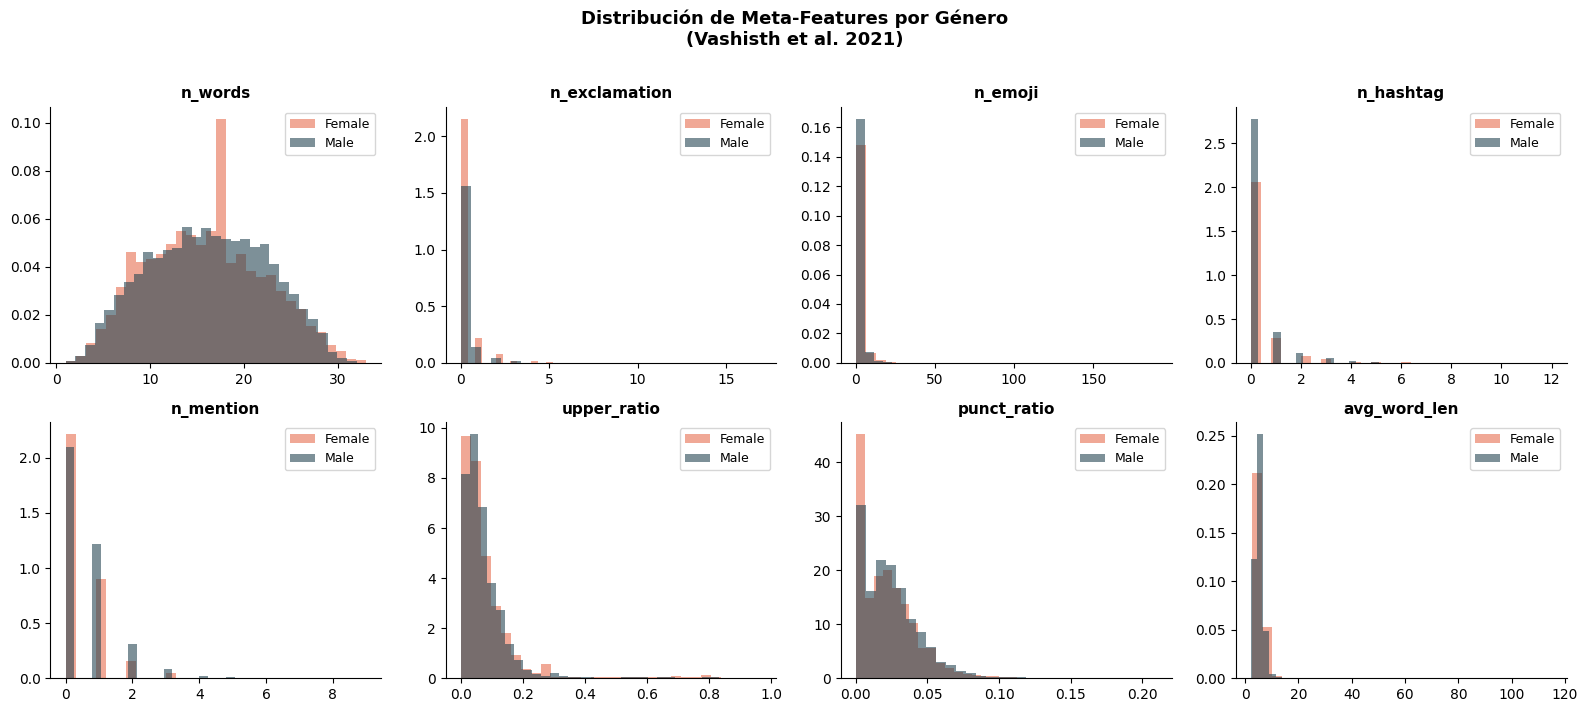

✅ Figura guardada: meta_features_dist.png


In [ ]:
# Visualizar diferencias por género en meta-features
meta_df['label'] = y
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
features_to_plot = ['n_words', 'n_exclamation', 'n_emoji', 'n_hashtag',
                    'n_mention', 'upper_ratio', 'punct_ratio', 'avg_word_len']

for ax, feat in zip(axes.flat, features_to_plot):
    for lbl, color, name in [(0, '#E76F51', 'Female'), (1, '#264653', 'Male')]:
        data = meta_df[meta_df['label'] == lbl][feat]
        ax.hist(data, bins=30, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Distribución de Meta-Features por Género\n(Vashisth et al. 2021)', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('meta_features_dist.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Figura guardada: meta_features_dist.png')

In [12]:
# Split estratificado
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF: word-level + char-level (moraleja Paper 1: char n-grams capturan patrones ortográficos de género)
tfidf_word = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=3, sublinear_tf=True)
tfidf_char = TfidfVectorizer(max_features=3000, ngram_range=(2, 4), analyzer='char_wb', sublinear_tf=True)

X_train_word = tfidf_word.fit_transform(X_train_text)
X_test_word  = tfidf_word.transform(X_test_text)

X_train_char = tfidf_char.fit_transform(X_train_text)
X_test_char  = tfidf_char.transform(X_test_text)

# Meta-features
meta_train = extract_meta_features(X_train_text)
meta_test  = extract_meta_features(X_test_text)

# Combinar: TF-IDF word + TF-IDF char + meta-features
X_train = hstack([X_train_word, X_train_char, csr_matrix(meta_train.values)])
X_test  = hstack([X_test_word,  X_test_char,  csr_matrix(meta_test.values)])

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (10315, 11012) | Test: (2579, 11012)


## 3 · Modelo Principal: Random Forest
**Bagging** — entrenamiento paralelo con subconjuntos aleatorios de datos y features (Slides 74-75).

In [13]:
# ─── Entrenamiento base ───
rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
rf_base.fit(X_train, y_train)
y_pred_rf = rf_base.predict(X_test)

print('=== Random Forest Base ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_rf, average="weighted"):.4f}')
print(f'AUC-ROC  : {roc_auc_score(y_test, rf_base.predict_proba(X_test)[:,1]):.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['Female', 'Male']))

=== Random Forest Base ===
Accuracy : 0.6444
F1-Score : 0.6438
AUC-ROC  : 0.6928

              precision    recall  f1-score   support

      Female       0.65      0.68      0.67      1340
        Male       0.64      0.60      0.62      1239

    accuracy                           0.64      2579
   macro avg       0.64      0.64      0.64      2579
weighted avg       0.64      0.64      0.64      2579



## 4 · Protocolo Experimental
**Punto 6 del rubric:** Analizar efecto de variables independientes e identificar mejores configuraciones.

In [14]:
# ─── Variables experimentales para Random Forest ───
# Inspirado en Vashisth et al.: comparar impacto de hiperparámetros clave

param_grid = {
    'n_estimators' : [50, 100, 200, 300],
    'max_depth'    : [None, 10, 20, 30],
    'max_features' : ['sqrt', 'log2'],
}

# GridSearch con CV estratificado
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=42),
    param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    refit=True
)
rf_grid.fit(X_train, y_train)

print(f'\n✅ Mejor configuración: {rf_grid.best_params_}')
print(f'   F1 CV (mejor): {rf_grid.best_score_:.4f}')

# Modelo optimizado
rf_best = rf_grid.best_estimator_
y_pred_best = rf_best.predict(X_test)
print(f'\nTest Accuracy : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'Test F1-Score : {f1_score(y_test, y_pred_best, average="weighted"):.4f}')

Fitting 5 folds for each of 32 candidates, totalling 160 fits

✅ Mejor configuración: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200}
   F1 CV (mejor): 0.6166

Test Accuracy : 0.6402
Test F1-Score : 0.6398


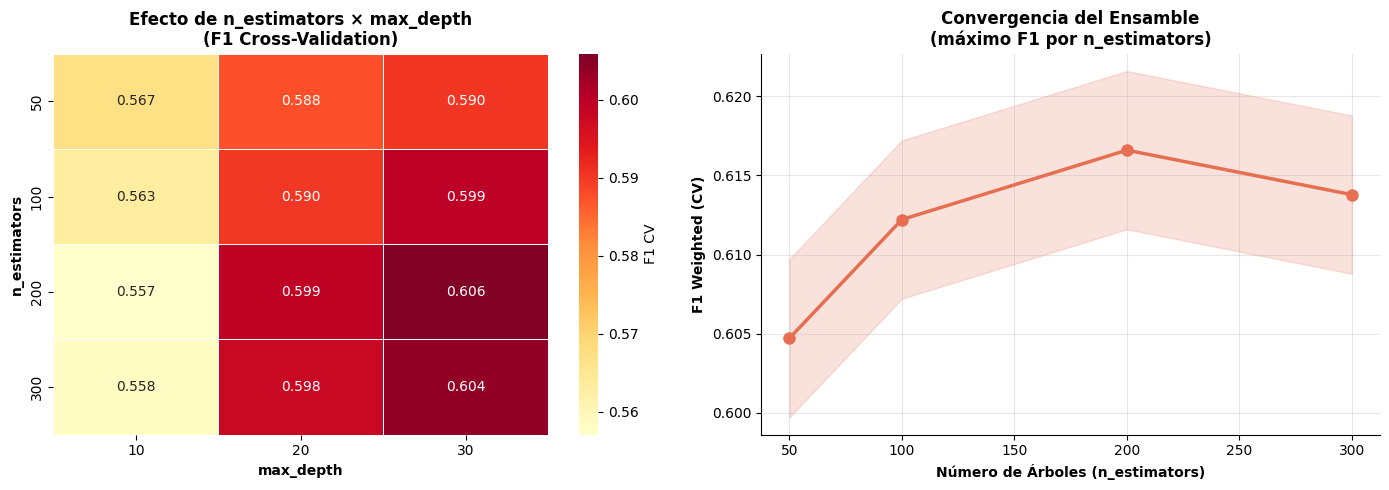

✅ Figura guardada: rf_hyperparams_analysis.png


In [ ]:
# ─── Análisis del efecto de n_estimators (figura clave para la presentación) ───
results_cv = pd.DataFrame(rf_grid.cv_results_)

# Promedio por n_estimators
pivot = results_cv.pivot_table(
    index='param_n_estimators',
    columns='param_max_depth',
    values='mean_test_score'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de hiperparámetros
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[0], linewidths=0.5, cbar_kws={'label': 'F1 CV'})
axes[0].set_title('Efecto de n_estimators × max_depth\n(F1 Cross-Validation)', 
                  fontweight='bold')
axes[0].set_xlabel('max_depth', fontweight='bold')
axes[0].set_ylabel('n_estimators', fontweight='bold')

# Curva de aprendizaje por n_estimators
ne_scores = results_cv.groupby('param_n_estimators')['mean_test_score'].max()
axes[1].plot(ne_scores.index.astype(int), ne_scores.values, 'o-', 
             color='#E76F51', linewidth=2.5, markersize=8)
axes[1].fill_between(ne_scores.index.astype(int), ne_scores.values - 0.005,
                     ne_scores.values + 0.005, alpha=0.2, color='#E76F51')
axes[1].set_xlabel('Número de Árboles (n_estimators)', fontweight='bold')
axes[1].set_ylabel('F1 Weighted (CV)', fontweight='bold')
axes[1].set_title('Convergencia del Ensamble\n(máximo F1 por n_estimators)', fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rf_hyperparams_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Figura guardada: rf_hyperparams_analysis.png')

## 5 · Modelo de IA Detallado — Feature Importance
Random Forest permite ver **qué features importan más** — esto hace interpretable el modelo (algo que MLP no ofrece directamente).

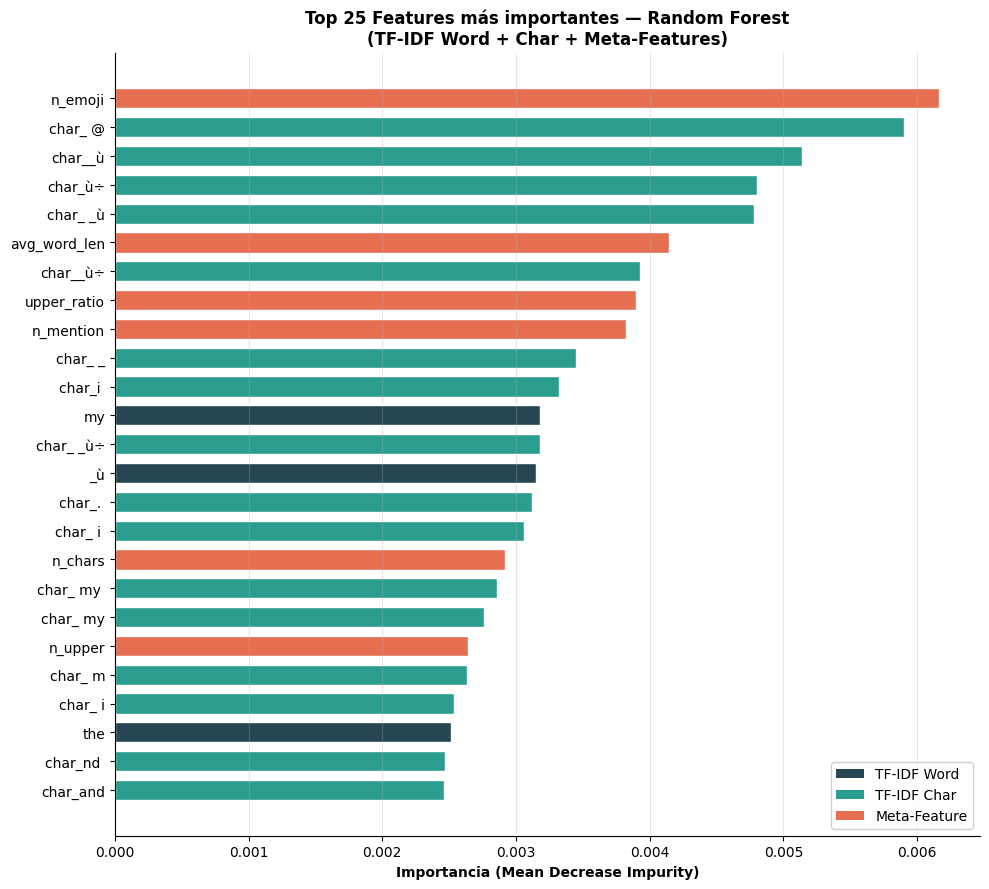

✅ Figura guardada: feature_importance.png

Top 5 features:
        feature  importance          type
11008   n_emoji    0.006163  Meta-Feature
8036    char_ @    0.005905   TF-IDF Char
8668    char__ù    0.005137   TF-IDF Char
10988   char_ù÷    0.004800   TF-IDF Char
8062   char_ _ù    0.004779   TF-IDF Char


In [ ]:
# Reconstruir nombres de features
word_feat_names = tfidf_word.get_feature_names_out().tolist()
char_feat_names = [f'char_{f}' for f in tfidf_char.get_feature_names_out()]
meta_feat_names = [
    'n_chars', 'n_words', 'n_upper', 'n_punct', 'n_exclamation',
    'n_question', 'n_hashtag', 'n_mention', 'n_emoji',
    'avg_word_len', 'upper_ratio', 'punct_ratio'
]
all_feat_names = word_feat_names + char_feat_names + meta_feat_names

# Feature importances
importances = rf_best.feature_importances_
feat_df = pd.DataFrame({'feature': all_feat_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False)

top_n = 25
top_feats = feat_df.head(top_n)

# Separar por tipo
def feat_type(name):
    if name in meta_feat_names: return 'Meta-Feature'
    if name.startswith('char_'): return 'TF-IDF Char'
    return 'TF-IDF Word'

top_feats['type'] = top_feats['feature'].apply(feat_type)
color_map = {'TF-IDF Word': '#264653', 'TF-IDF Char': '#2A9D8F', 'Meta-Feature': '#E76F51'}

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(range(top_n), top_feats['importance'].values,
               color=[color_map[t] for t in top_feats['type']],
               edgecolor='white', height=0.7)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_feats['feature'].values, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Importancia (Mean Decrease Impurity)', fontweight='bold')
ax.set_title(f'Top {top_n} Features más importantes — Random Forest\n(TF-IDF Word + Char + Meta-Features)', 
             fontweight='bold', fontsize=12)

# Leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
ax.legend(handles=legend_elements, loc='lower right', framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Figura guardada: feature_importance.png')
print(f'\nTop 5 features:\n{top_feats[["feature","importance","type"]].head()}')

## 6 · Tabla Comparativa — Todas las Fases del Proyecto
Contexto acumulado: LR → Perceptron → MLP → DE-MLP → **RF (esta fase)**

In [17]:
# ─── AJUSTAR: ingresar métricas de las fases anteriores ───
# Reemplazar los valores con los resultados reales del repo

results_history = {
    'Modelo': [
        'Logistic Regression',
        'Perceptron',
        'MLP (manual)',
        'MLP + DE (Fase 1)',   # <-- resultado ganador de la fase anterior
        'Random Forest (base)',
        'Random Forest (optimizado)',
    ],
    'Accuracy': [0.00, 0.00, 0.00, 0.00,   # <-- REEMPLAZAR con valores reales
                 round(accuracy_score(y_test, y_pred_rf), 4),
                 round(accuracy_score(y_test, y_pred_best), 4)],
    'F1-Weighted': [0.00, 0.00, 0.00, 0.00,  # <-- REEMPLAZAR
                    round(f1_score(y_test, y_pred_rf, average='weighted'), 4),
                    round(f1_score(y_test, y_pred_best, average='weighted'), 4)],
    'AUC-ROC': [0.00, 0.00, 0.00, 0.00,  # <-- REEMPLAZAR
                round(roc_auc_score(y_test, rf_base.predict_proba(X_test)[:,1]), 4),
                round(roc_auc_score(y_test, rf_best.predict_proba(X_test)[:,1]), 4)],
    'Fase': ['Prev', 'Prev', 'Prev', 'Fase 1 (EA)', 'Fase 2 (AM)', 'Fase 2 (AM)'],
    'Módulo': ['Base', 'Base', 'Base', 'EA-DE', 'AM-RF', 'AM-RF+GS'],
}

df_results = pd.DataFrame(results_history)
print('=== Tabla Comparativa General ===')
df_results.style.background_gradient(subset=['Accuracy','F1-Weighted','AUC-ROC'], cmap='YlOrRd')

=== Tabla Comparativa General ===


,Modelo,Accuracy,F1-Weighted,AUC-ROC,Fase,Módulo
0,Logistic Regression,0.000000,0.000000,0.000000,Prev,Base
1,Perceptron,0.000000,0.000000,0.000000,Prev,Base
2,MLP (manual),0.000000,0.000000,0.000000,Prev,Base
3,MLP + DE (Fase 1),0.000000,0.000000,0.000000,Fase 1 (EA),EA-DE
4,Random Forest (base),0.644400,0.643800,0.692800,Fase 2 (AM),AM-RF
5,Random Forest (optimizado),0.640200,0.639800,0.692000,Fase 2 (AM),AM-RF+GS


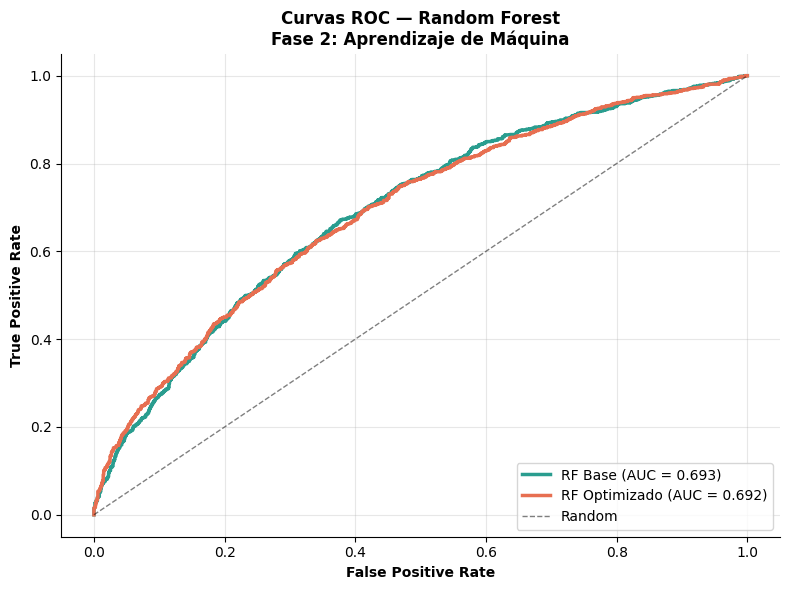

✅ Figura guardada: roc_curves.png


In [ ]:
# Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(8, 6))

models_roc = [
    ('RF Base', rf_base),
    ('RF Optimizado', rf_best),
]

colors = ['#2A9D8F', '#E76F51']
for (name, model), color in zip(models_roc, colors):
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('Curvas ROC — Random Forest\nFase 2: Aprendizaje de Máquina', fontweight='bold')
ax.legend(loc='lower right')
ax.spines[['top','right']].set_visible(False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figura guardada: roc_curves.png')

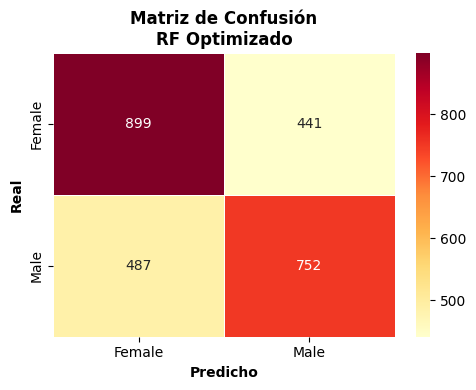

In [19]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Female','Male'],
            yticklabels=['Female','Male'],
            linewidths=0.5, ax=ax)
ax.set_ylabel('Real', fontweight='bold')
ax.set_xlabel('Predicho', fontweight='bold')
ax.set_title('Matriz de Confusión\nRF Optimizado', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

## 7 · Guardar modelos entrenados

In [ ]:
joblib.dump(rf_best,    'rf_best_model.pkl')
joblib.dump(tfidf_word, 'tfidf_word.pkl')
joblib.dump(tfidf_char, 'tfidf_char.pkl')
print('✅ Modelos guardados: rf_best_model.pkl, tfidf_word.pkl, tfidf_char.pkl')

# Guardar tabla de resultados
df_results.to_csv('resultados_comparativos.csv', index=False)
feat_df.to_csv('feature_importances.csv', index=False)
print(' CSVs guardados')

---
## 8 · 🎛️ Dashboard Interactivo — Gradio
**Tres tabs:** Clasificar tweet en vivo · Comparar modelos · Explorar features por género

> Lanzar con `demo.launch(inline=True)` para que aparezca directamente en el notebook.

In [ ]:
import gradio as gr
from wordcloud import WordCloud
import io
from PIL import Image

# ─── Función de predicción ───
def predict_gender(tweet_text):
    if not tweet_text.strip():
        return "⚠️ Ingresa un tweet", None, ""

    # Features
    word_f  = tfidf_word.transform([tweet_text])
    char_f  = tfidf_char.transform([tweet_text])
    meta_f  = csr_matrix(extract_meta_features([tweet_text]).values)
    X_input = hstack([word_f, char_f, meta_f])

    proba  = rf_best.predict_proba(X_input)[0]
    pred   = rf_best.predict(X_input)[0]
    label  = '♀️ Femenino' if pred == 0 else '♂️ Masculino'
    conf   = proba[pred] * 100

    # Top features que activaron esta predicción (palabras del tweet en el vocabulario)
    words_in_tweet = [w.lower() for w in tweet_text.split()]
    top_active = feat_df[feat_df['feature'].isin(words_in_tweet)].head(5)
    feat_info  = top_active[['feature','importance']].to_string(index=False) if not top_active.empty else 'N/A'

    # Gráfico de probabilidades
    fig_proba, ax = plt.subplots(figsize=(5, 2.2))
    labels = ['Femenino', 'Masculino']
    colors = ['#E76F51' if p == max(proba) else '#B0BEC5' for p in proba]
    bars = ax.barh(labels, proba * 100, color=['#E76F51','#264653'], height=0.5)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Probabilidad (%)')
    ax.set_title(f'Predicción: {label} ({conf:.1f}%)', fontweight='bold')
    for bar, val in zip(bars, proba):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{val*100:.1f}%', va='center', fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()

    result_text = f"{label} — Confianza: {conf:.1f}%"
    features_text = f"Top features activos del tweet:\n{feat_info}"
    return result_text, fig_proba, features_text


# ─── Función comparación de modelos ───
def show_model_comparison():
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Bar chart de accuracy y F1
    df_plot = df_results[df_results['Accuracy'] > 0].copy()
    x = np.arange(len(df_plot))
    w = 0.35
    axes[0].bar(x - w/2, df_plot['Accuracy'], w, label='Accuracy', color='#264653', alpha=0.9)
    axes[0].bar(x + w/2, df_plot['F1-Weighted'], w, label='F1-Weighted', color='#E76F51', alpha=0.9)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(df_plot['Modelo'], rotation=35, ha='right', fontsize=9)
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel('Score')
    axes[0].set_title('Accuracy & F1 por Modelo', fontweight='bold')
    axes[0].legend()
    axes[0].spines[['top','right']].set_visible(False)
    axes[0].grid(axis='y', alpha=0.3)

    # AUC-ROC
    axes[1].bar(x, df_plot['AUC-ROC'], color='#2A9D8F', alpha=0.9)
    axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(df_plot['Modelo'], rotation=35, ha='right', fontsize=9)
    axes[1].set_ylim(0, 1.05)
    axes[1].set_ylabel('AUC-ROC')
    axes[1].set_title('AUC-ROC por Modelo', fontweight='bold')
    axes[1].legend()
    axes[1].spines[['top','right']].set_visible(False)
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    return fig


# ─── Función wordcloud por género ───
def show_wordcloud(gender_choice):
    label_val = 0 if gender_choice == 'Femenino' else 1
    color = 'Reds' if label_val == 0 else 'Blues'

    texts = df[df['label'] == label_val][TEXT_COL].astype(str).tolist()
    combined = ' '.join(texts)

    wc = WordCloud(
        width=700, height=380,
        background_color='white',
        colormap=color,
        max_words=80,
        collocations=False
    ).generate(combined)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Palabras más frecuentes — Género {gender_choice}', fontweight='bold', fontsize=13)
    plt.tight_layout()
    return fig


# ─── Función top features ───
def show_top_features(n_features):
    n_features = int(n_features)
    top = feat_df.head(n_features).copy()
    top['type'] = top['feature'].apply(feat_type)
    color_list = [color_map.get(t, '#999') for t in top['type']]

    fig, ax = plt.subplots(figsize=(9, n_features * 0.38 + 1))
    ax.barh(range(n_features), top['importance'].values[::-1],
            color=color_list[::-1], edgecolor='white', height=0.7)
    ax.set_yticks(range(n_features))
    ax.set_yticklabels(top['feature'].values[::-1], fontsize=9)
    ax.set_xlabel('Importancia')
    ax.set_title(f'Top {n_features} Features — Random Forest', fontweight='bold')
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    return fig


print(' Funciones del dashboard definidas')

✅ Funciones del dashboard definidas


In [21]:
# ─── Construcción del dashboard ───
with gr.Blocks(
    title='Twitter Gender Classifier — Fase 2 AM',
    theme=gr.themes.Soft(primary_hue='orange', secondary_hue='teal'),
    css='.gradio-container { font-family: "Helvetica Neue", sans-serif; }'
) as demo:

    gr.Markdown("""
    # 🐦 Twitter Gender Classifier — Fase 2: Aprendizaje de Máquina
    **Técnica:** Random Forest (Ensemble · Bagging) · **Ref:** Vashisth et al. (2021) IEEE ICCMC
    """)

    with gr.Tabs():

        # ── TAB 1: Clasificar tweet ──────────────────────────────────────
        with gr.Tab('🔍 Clasificar Tweet'):
            gr.Markdown('### Ingresa un tweet para predecir el género del autor')
            with gr.Row():
                with gr.Column(scale=1):
                    tweet_input = gr.Textbox(
                        label='Tweet',
                        placeholder='Escribe o pega un tweet aquí...',
                        lines=3
                    )
                    predict_btn = gr.Button('🚀 Predecir', variant='primary')
                    result_label = gr.Textbox(label='Resultado', interactive=False)
                    features_info = gr.Textbox(label='Features activados', interactive=False, lines=6)
                with gr.Column(scale=1):
                    proba_plot = gr.Plot(label='Probabilidades')

            predict_btn.click(
                fn=predict_gender,
                inputs=[tweet_input],
                outputs=[result_label, proba_plot, features_info]
            )

            gr.Examples(
                examples=[
                    ['Just got my nails done, feeling amazing! 💅✨ #selfcare #girlsday'],
                    ['The match last night was insane!! That last-minute goal 🔥⚽ #UCL'],
                    ['Finished reading my book club pick. Beautiful story about grief and healing.'],
                    ['Just upgraded my PC setup, RTX 4090 finally arrived!! #gaming #pcbuild'],
                ],
                inputs=tweet_input
            )

        # ── TAB 2: Comparar modelos ──────────────────────────────────────
        with gr.Tab('📊 Comparar Modelos'):
            gr.Markdown("""### Evolución del desempeño a través de las fases del proyecto
            *Actualizar la tabla de resultados históricos con los valores reales de las fases anteriores.*""")
            compare_btn = gr.Button('🔄 Generar comparativa', variant='primary')
            compare_plot = gr.Plot(label='Comparación de modelos')
            compare_btn.click(fn=show_model_comparison, inputs=[], outputs=[compare_plot])

            gr.Markdown('#### Tabla de resultados')
            gr.Dataframe(
                value=df_results[['Modelo','Accuracy','F1-Weighted','AUC-ROC','Fase']],
                headers=['Modelo','Accuracy','F1-Weighted','AUC-ROC','Fase'],
                interactive=False
            )

        # ── TAB 3: Explorar features ─────────────────────────────────────
        with gr.Tab('🔤 Explorar Features'):
            gr.Markdown('### Importancia de features y vocabulario por género')
            with gr.Row():
                with gr.Column():
                    n_feat_slider = gr.Slider(5, 40, value=20, step=5,
                                              label='Top N features a mostrar')
                    feat_btn = gr.Button('📈 Mostrar importancia', variant='primary')
                    feat_plot = gr.Plot(label='Feature Importance')
                    feat_btn.click(fn=show_top_features, inputs=[n_feat_slider], outputs=[feat_plot])

                with gr.Column():
                    gender_radio = gr.Radio(
                        choices=['Femenino', 'Masculino'],
                        value='Femenino',
                        label='Género'
                    )
                    wc_btn = gr.Button('☁️ Generar WordCloud', variant='primary')
                    wc_plot = gr.Plot(label='WordCloud')
                    wc_btn.click(fn=show_wordcloud, inputs=[gender_radio], outputs=[wc_plot])

# Lanzar dashboard inline en el notebook
demo.launch(inline=True, share=False)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
